In [ ]:
# Week 2 Day 1: Logistic Regression

## Today's Goal

Today I will learn how Logistic Regression performs binary classification.

## Learning Objectives

- Understand linear scores and the sigmoid fuction
- Understand probability output and decision thresholds
- Train a Logistic Regression model
- Compare 'predict()' with 'predict_proba()'
- Interpret the model results

In [ ]:
## Prediction Before Running

#1. Will 'X' be one-dimensional or two-dimensional? Why?
I expect `X` to be two-dimensional because each row represents one sample, and each column represents one feature.

#2. Will 'y' be one-dimensional or two-dimensional? Why?
y will be one-dimensional because it stores one target label for each sample.

#3. How many target classes do I expect?
I expect that there will be two target classes because of binary classification.

#4. Do I expect all features to have similar numerical scales?
I hope but I expect it is hard in real researches and feature scaling may be necessary.

In [1]:
# Step 1: Load the dataset
from sklearn.datasets import load_breast_cancer
import numpy as np
import pandas as pd

data = load_breast_cancer()

# X contains the input features; y contains the true labels
X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", data.target_names)
print("Class counts:", np.bincount(y))

X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']
Class counts: [212 357]


In [2]:
# Step 2: Examine feature scales
feature_df = pd.DataFrame(X, columns=data.feature_names)

selected_features = [
    "mean radius",
    "mean area",
    "mean smoothness"
]

feature_stats = feature_df[selected_features].agg(
    ["min", "max", "mean", "std"]
).T

feature_stats

,min,max,mean,std
mean radius,6.98100,28.1100,14.127292,3.524049
mean area,143.50000,2501.0000,654.889104,351.914129
mean smoothness,0.05263,0.1634,0.096360,0.014064


In [ ]:
## Feature Scale Interpretation

The three features have very different numerical scales.

`mean area` has the largest values, while `mean smoothness` has the
smallest values. This supports my prediction.

However, a larger numerical value does not necessarily mean that the
feature is more important. Feature scaling is needed so that the model
can treat features on a more comparable scale.

In [5]:
# Step 3: Split the dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Fit the scaler only on the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Use the traing-set statistics to transform the test data
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Training class proportions:", np.bincount(y_train)/len(y_train))
print("Test class proportions:", np.bincount(y_test)/len(y_test))

print("First three scaled means:",
      X_train_scaled.mean(axis=0)[:3])

print("First three scaled standard deviations:",
      X_train_scaled.std(axis=0)[:3])

X_train shape: (455, 30)
X_test shape: (114, 30)
Training class proportions: [0.37362637 0.62637363]
Test class proportions: [0.36842105 0.63157895]
First three scaled means: [-4.31742554e-15  2.24606658e-15 -7.38359313e-16]
First three scaled standard deviations: [1. 1. 1.]


In [7]:
# Step 4: Train a Logistic Regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

#Predict classes and probabilities
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

print("Coefficient shape:", model.coef_.shape)
print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_proba.shape)
print("Class order:", model.classes_)

print("\nFirst five predicted classes:")
print(y_pred[:5])

print("\nFirst five predicted probability:")
print(y_proba[:5])

print("\nprobability sums:")
print(y_proba[:5].sum(axis=1))

Coefficient shape: (1, 30)
Prediction shape: (114,)
Probability shape: (114, 2)
Class order: [0 1]

First five predicted classes:
[0 1 0 1 0]

First five predicted probability:
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]

probability sums:
[1. 1. 1. 1. 1.]


In [10]:
# Step 5: Evaluate the model on the test set
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)
majority_baseline = np.max(np.bincount(y_test)/len(y_test))

print("Majority-class baseline:", majority_baseline)
print("Logistic Regression accuracy:", test_accuracy)
print("Correct prediction:", np.sum(y_test == y_pred))
print("Incorrect prediction:", np.sum(y_test != y_pred))

Majority-class baseline: 0.631578947368421
Logistic Regression accuracy: 0.9824561403508771
Correct prediction: 112
Incorrect prediction: 2


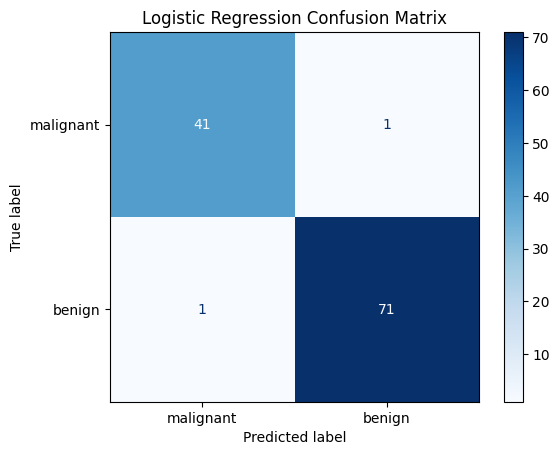

[[41  1]
 [ 1 71]]


In [14]:
# Step 6: Examine the confusion matrix
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

display.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print(cm)

In [ ]:
# Reflection

## 1. What did I learn today?
I learnt a new model to deal with classification problem called Logistic regression and I knew the principle and steps of this model with 
the research of breast cancer datasets.

## 2. What surprised me?
The model make a classifiaction by probability with formula computation.

## 3. What mistakes did I make?
I was confused by the shape of coefficient in the datasets.

## 4. Explain Logistic regression in my words.
Logistic regression is a model, claculating all features by a formula which model will learn from train datasets and get the value of z. 
Then z will transform into the proability by Sigmoid and the model make a classification by Decision threshold with the proability.

## 5. Result Interpretation
The model make a good classification accuracy, compared with majority-class baseline.

The model correctly classified 41 malignant samples and 41 benign samples.

It incorrectly classified 1 malignant sample as benign and 1 benign sample as malignant.

The test accuracy was 0.982, which was much higher than the majority-class baseline of 0.632.